/home/skipjack/Document/cold_plasma_dipassive/.venv/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:240: ComplexWarning: Casting complex values to real discards the imaginary part
  retval = _minpack._hybrd(func, x0, args, 1, xtol, maxfev,
/home/skipjack/Document/cold_plasma_dipassive/.venv/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


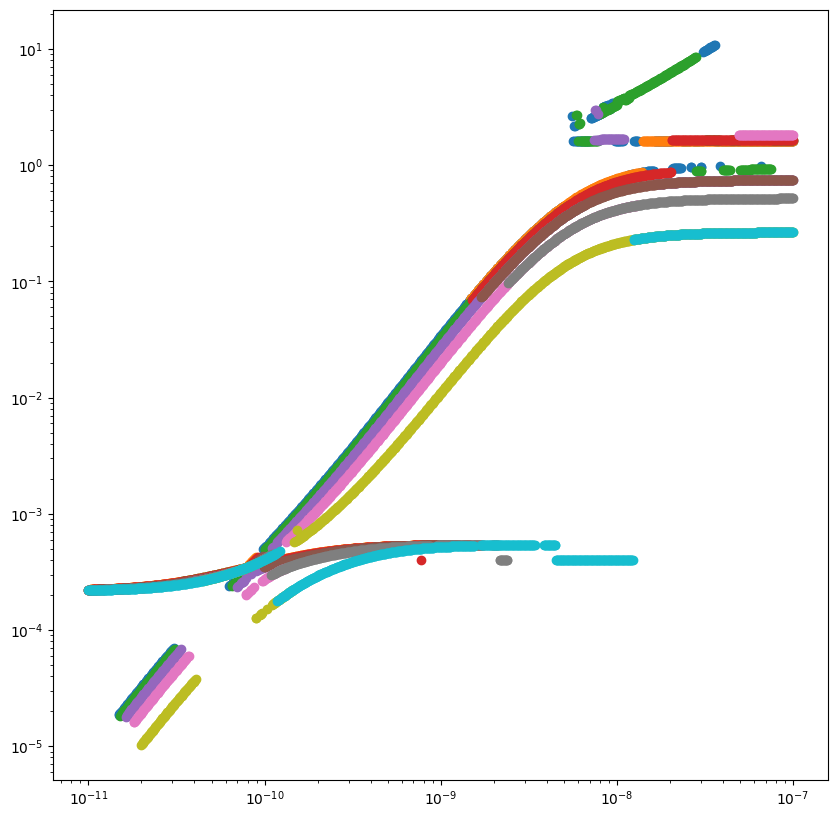

In [88]:
import numpy as np
import matplotlib.pyplot as plt
# 並列化用ライブラリ、引数操作用ライブラリをインポート
import multiprocessing
from functools import partial
from scipy.optimize import fsolve


#質量
#プラズマ周波数(電子のサイクロトロン周波数で規格化)
#サイクロトロン周波数(電子のサイクロトロン周波数で規格化)
# Constants
c = 3e8
me = 9.1093837015e-31
mh = 1.67262192e-27
a = 0.6 # proton and oxygen ratio
electron_cycltrons_seconds = 1

# Initialize plasma parameters
def init_plasma_params():
    oe, pe = 1.0*electron_cycltrons_seconds , 1.6*electron_cycltrons_seconds
    protons = {
        "mass": mh,
        "charge_sign": 1.0,
        "Cyclotron_freq": oe * me / mh,
        "Plasma_freq": pe * np.sqrt(a * me / mh),
        "name":"proton"
    }

    electrons = {
        "mass": me,
        "charge_sign": -1.0,
        "Cyclotron_freq": oe,
        "Plasma_freq": pe,
        "name": "electron"
    }
    return {"electron": electrons, "proton": protons}

elements = init_plasma_params()

if("electron" in elements):
  electron_plasma_freq = elements["electron"]["Plasma_freq"]
  electron_plasma_cycltrons = elements["electron"]["Cyclotron_freq"]
if("proton" in elements):
  proton_plasma_freq = elements["proton"]["Plasma_freq"]
  proton_plasma_cycltrons = elements["proton"]["Cyclotron_freq"]


# 分散関係の計算を関数化
def calc_disp(w,wave_num_tensor):
  K_perp = 1.0+0.0j
  K_x = 0.0j
  K_para = 1.0+0.0j

  for element in elements.values():
    plasma_frequencies = element["Plasma_freq"]
    plasma_cycltrons = element["Cyclotron_freq"]
    charge_sign = element["charge_sign"]
    K_perp -= plasma_frequencies**2.0/(w[0]**2.0-plasma_cycltrons**2.0)
    K_x += plasma_frequencies**2.0/(w[0]**2.0-plasma_cycltrons**2.0)*plasma_cycltrons*charge_sign/w[0]
    K_para -= plasma_frequencies**2.0/w[0]**2.0

  K_tensor = np.array([[K_perp,-1.0j*K_x,0.0j],[1.0j*K_x,K_perp,0.0j],[0.0j,0.0j,K_para]])


  matrix = w[0]**2.0/c**2.0*K_tensor + wave_num_tensor

  det = np.linalg.det(matrix)

  return det 

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 10))
#ax1.set_ylim(1e-6,1)

ax1.set_xscale('log')
ax1.set_yscale('log')


array_num = 1000
k_array = np.logspace(-11.0,-7.0,array_num)
w_res = np.zeros(array_num)
w_res2 = np.zeros(array_num)
theta_list = np.arange(0,0.5*np.pi,0.1*np.pi)

Gamma_val = np.zeros((3,3,3))



for theta_index, theta in np.ndenumerate(theta_list):

  for k_index, k in np.ndenumerate(k_array):
    k1 = k*np.cos(theta)
    k2 = k*np.sin(theta)
    k3 = 0
    wave_num_tensor = np.full((3, 3), 0.0+0.0j)

    wave_num_tensor = 0.0j+np.array([[-k1**2.0,0.0,k1*k2],[0,-(k1**2.0+k2**2.0),0.0],[k1*k2,0.0,-k2**2.0]])
    res = fsolve(calc_disp,1e-1,args = wave_num_tensor)
    res2 = fsolve(calc_disp,4e-4,args = wave_num_tensor,maxfev=10000)
    w_res[k_index] = res.real
    w_res2[k_index] = res2.real
  ax1.scatter(k_array,w_res)
  ax1.scatter(k_array,w_res2)